# Check Composition

## Sample All

In [ ]:
all_data_sample = pd.read_parquet('../data/nosalary_sample_body.parquet.gzip')

In [ ]:
all_data_sample

,ID,CITY_NAME,COUNTY_NAME,STATE_NAME,NAICS_2022_2,NAICS_2022_2_NAME,MIN_EDULEVELS_NAME,EMPLOYMENT_TYPE,EMPLOYMENT_TYPE_NAME,IS_INTERNSHIP,...,COMPANY_NAME,COMPANY_RAW,Has AI Skills,wfh_wham_prob,wfh_wham,YEAR,SALARY,BODY,BLS_NAICS,BLS_industry
0,8a93d0d9e7fbdb76acc0e9f548d925ab1247db06,"Santa Clara, CA","Santa Clara, CA",California,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,...,Nvidia,Nvidia,True,0.002,0.0,2019,NaN,Job Information\n\nNvidia Framework Build and ...,31.0,Manufacturing
1,e0586f94f1eea340e1acb065148dae1d1665bfd0,"Fort Worth, TX","Tarrant, TX",Texas,31,Manufacturing,Bachelor's degree,1,Full-time (> 32 hours),False,...,Textron,Textron Inc.,True,0.010,0.0,2019,NaN,# Embedded Software Engineer\n\nBell is seekin...,31.0,Manufacturing
2,dcba3b678fd61a8bfab9022295f3011519a819dc,"Sunnyvale, CA","Santa Clara, CA",California,42,Wholesale Trade,Master's degree,1,Full-time (> 32 hours),False,...,Juniper Networks,Telecoms.com,True,0.005,0.0,2021,NaN,Data Scientist Staff - AI/ML\n\nAdvertiser\n\n...,42.0,Wholesale trade
3,1328c18057afd2256152b7ca21c4ab389bbe4051,"San Jose, CA","Santa Clara, CA",California,51,Information,Bachelor's degree,1,Full-time (> 32 hours),False,...,Adobe,Adobe,True,0.013,0.0,2022,NaN,"Data Platform SRE Adobe - 4.3 San Jose, CA App...",51.0,Information
4,7c3eafe685651099d119c2967118c08ab38b4019,"Dallas, TX","Dallas, TX",Texas,42,Wholesale Trade,Bachelor's degree,1,Full-time (> 32 hours),False,...,MSC Industrial Direct,MSC Industrial Supply,True,0.001,0.0,2020,NaN,Key Account Sales Consultant\n\nMSC Industrial...,42.0,Wholesale trade
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,40e5b95ae2306d19d73720095704e31feb1f316c,"New York, NY","Queens, NY",New York,23,Construction,High school or GED,3,Part-time / full-time,False,...,Khaika Construction,Khaika Construction,False,0.001,0.0,2021,28600.0,Delivery Driver\n\nKhaika Construction -\n\nQu...,23.0,Construction
19996,93dc88abfc674370c835db57f2d434522e8145a5,"Portland, OR","Washington, OR",Oregon,31,Manufacturing,No Education Listed,1,Full-time (> 32 hours),False,...,Curtiss-Wright,"Curtiss-Wright Controls, Inc.",False,0.385,0.0,2023,NaN,Inside Sales Support Engineer- Onsite/Hybrid P...,31.0,Manufacturing
19997,6999b9cc1b8049c2bff3978640af885475065781,"Plymouth, MA","Plymouth, MA",Massachusetts,92,Public Administration,Bachelor's degree,1,Full-time (> 32 hours),False,...,Town Of Plymouth,Town of Plymouth,False,0.001,0.0,2023,100152.0,The town of Plymouth seeks qualified applicant...,NaN,Public Administration
19998,a4110c1ddf5beda1e47824f557a57ec5cb8f567f,"Phoenix, AZ","Maricopa, AZ",Arizona,72,Accommodation and Food Services,No Education Listed,1,Full-time (> 32 hours),False,...,Wendy's,Wendy's,False,0.001,0.0,2020,NaN,"Shift Supervisors at Wendy's in Phoenix, Arizo...",72.0,Leisure and hospitality


In [ ]:
salary_data_sample = pd.read_parquet('../data/salary_sample_body.parquet.gzip')

In [ ]:
industry_crosswalk = pd.read_csv('../../thesis/Resources/Expanded_NAICS_Code_to_Industry_Name_Crosswalk.csv')

In [ ]:
industry_crosswalk = industry_crosswalk.rename(columns = {'Industry name': 'BLS_industry'})

In [ ]:
industry_crosswalk.dropna(inplace=True)

In [ ]:
industry_crosswalk['NAICS code'] = industry_crosswalk['NAICS code'].astype(int)

In [ ]:
industry_crosswalk = industry_crosswalk.rename(columns = {'NAICS code': 'BLS_NAICS'})

In [ ]:
all_data_sample = all_data_sample.merge(industry_crosswalk, left_on = 'NAICS_2022_2', right_on = 'BLS_NAICS', how = 'left')

In [ ]:
all_data_sample.loc[all_data_sample['BLS_industry'].isna(), 'BLS_industry'] = all_data_sample.loc[all_data_sample['BLS_industry'].isna(), 'NAICS_2022_2_NAME']

In [ ]:
all_data_sample.groupby('BLS_industry', dropna=False).size()

BLS_industry
Agriculture, forestry, fishing, and hunting wage and salary      23
Construction                                                    253
Education services                                              775
Financial activities                                           1928
Health care and social assistance                              1688
Information                                                    1056
Leisure and hospitality                                         722
Manufacturing                                                  1896
Mining                                                           31
Other services                                                  307
Professional and business services                             5709
Public Administration                                           225
Retail trade                                                   1435
Transportation and warehousing                                  347
Unclassified Industry              

In [ ]:
all_data_sample.to_parquet('../data/nosalary_sample_body.parquet.gzip', compression='gzip')

In [ ]:
def get_grouped_industry(data):
    grouped_industry = data.groupby('BLS_industry', dropna=False).size().reset_index(name='count')

    # Calculate the total count
    total_count = grouped_industry['count'].sum()

    # Calculate the percentage of each group
    grouped_industry['percentage'] = (grouped_industry['count'] / total_count) * 100

    return grouped_industry


In [ ]:
grouped_industry = get_grouped_industry(all_data_sample)

In [ ]:
bls_stats = pd.read_csv('../../thesis/Resources/Employment_by_Industry.csv')

In [ ]:
industry_comp = grouped_industry.merge(bls_stats, left_on = 'BLS_industry', right_on = 'Industry name', how = 'outer')

In [ ]:
industry_comp = industry_comp[['BLS_industry', 'Industry name','percentage', 'Percent distribution 2022']]

In [ ]:
industry_comp.rename(columns = {'percentage': 'OJV Data', 'Percent distribution 2022': 'National Statistics'}, inplace=True)

In [ ]:
industry_comp

,BLS_industry,Industry name,OJV Data,National Statistics
0,NaN,"Agriculture, forestry, fishing, and hunting se...",NaN,0.5
1,"Agriculture, forestry, fishing, and hunting wa...","Agriculture, forestry, fishing, and hunting wa...",0.115,0.9
2,Construction,Construction,1.265,4.7
3,Education services,Education services,3.875,2.3
4,NaN,Federal government,NaN,1.7
5,Financial activities,Financial activities,9.640,5.5
6,Health care and social assistance,Health care and social assistance,8.440,12.5
7,Information,Information,5.280,1.9
8,Leisure and hospitality,Leisure and hospitality,3.610,9.6
9,Manufacturing,Manufacturing,9.480,7.8


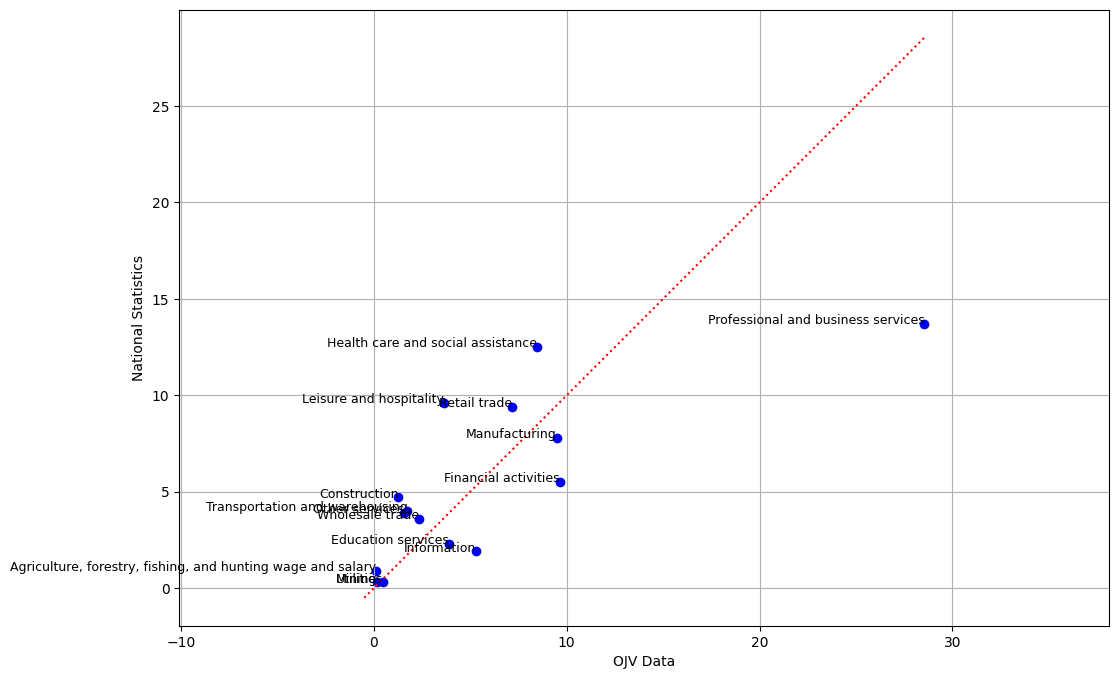

In [ ]:
import matplotlib.pyplot as plt

# Filter out rows with missing values in either column
filtered_df = industry_comp.dropna(subset=['OJV Data', 'National Statistics'])

# Create a scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(filtered_df['OJV Data'], filtered_df['National Statistics'], color='blue')

# Add labels for each point
for i, row in filtered_df.iterrows():
    plt.text(row['OJV Data'], row['National Statistics'], row['BLS_industry'], fontsize=9, ha='right')

# Set the labels and title
plt.xlabel('OJV Data')
plt.ylabel('National Statistics')
max_val = max(filtered_df['OJV Data'].max(), filtered_df['National Statistics'].max()) * 1

plt.plot([-0.5, max_val], [-0.5, max_val], linestyle='dotted', color='red')

# plt.title('Percentage vs National Statistics by BLS Industry')
plt.axis('equal')
# plt.xlim(0, max(filtered_df['OJV Data'].max(), filtered_df['National Statistics'].max()) * 1.1)
# plt.ylim(0, max(filtered_df['OJV Data'].max(), filtered_df['National Statistics'].max()) * 1.1)

# Show the plot
# Show the plot
plt.grid(True)
# save plot
plt.savefig('../figures/industry_comp_sampleall.png')
plt.show()
